In [132]:
import os
import glob
import pandas as pd
import os
import json
import numpy as np
import datetime
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [133]:
# Load historical data
path = "data/historical/*.csv" 
all_files = glob.glob(path)
existing_symbols = []
    
historical_list = []
for i, filename in enumerate(all_files):
    historical = pd.read_csv(filename, index_col=None, header=0, encoding='utf-8')
    symbol = os.path.basename(filename).split('.')[0]
    existing_symbols.append(symbol)
    historical['ibkr-symbol'] = symbol
    historical = historical.drop(['volume', 'average', 'barCount'], axis=1)
    historical_list.append((symbol, historical))

In [237]:
# Load analisis data and filter out rows that don't have historical data
df = pd.read_csv('data/analisis.csv')
df = df[df['ibkr-symbol'].isin(existing_symbols)]

In [135]:
data = pd.DataFrame(columns=['date'])
for stock_data in historical_list:
    stock_data[1]['date'] = pd.to_datetime(stock_data[1]['date'])
    temp = stock_data[1][['date', 'close']]
    temp = temp.rename(columns={'close':stock_data[0]})
    data = data.merge(temp, on='date', how='outer')

In [136]:
data.drop('date', axis=1).pct_change().std().sort_values().tail(30)

/var/folders/35/xfdc6bm10c98tsfyqbkl8vq80000gn/T/ipykernel_35883/3953772522.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data.drop('date', axis=1).pct_change().std().sort_values().tail(30)


3SAX     0.118411
3LOR     0.120527
3SQE     0.120662
NGA3S    0.122845
3PRE     0.123179
3LPA     0.125618
3LMO     0.126906
3LSQ     0.128396
3SLV     0.128871
3SPA     0.129160
3LIE     0.133784
3SSE     0.136894
3SSQ     0.137838
3NIE     0.140681
3SNI     0.140687
3SSN     0.143641
SNIE     0.145099
3SDA     0.149151
3LSE     0.153335
3XPV     0.155513
3STO     0.156651
SXEE     0.157037
S3CO     0.158228
3SMI     0.181643
3LMI     0.182108
3LCO     0.191471
ETZD     0.247582
ESEH     0.276838
3LLV     0.509476
CSW      0.955164
dtype: float64

In [144]:
def getHistoricalRange(start_date, end_date):

    # Get data slice
    mask = (data['date'] >= start_date) & (data['date'] <= end_date)
    subset = data.loc[mask]
    return subset

# corr = getHistoricalRange('2021-12-31', '2022-12-31')
subset = getHistoricalRange('2022-12-31', '2024-06-01')

corr = subset.drop('date', axis=1).reset_index(drop=True).pct_change().drop(df.index[0]).dropna(axis=1).corr()

/var/folders/35/xfdc6bm10c98tsfyqbkl8vq80000gn/T/ipykernel_35883/3740833949.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  corr = subset.drop('date', axis=1).reset_index(drop=True).pct_change().drop(df.index[0]).dropna(axis=1).corr()


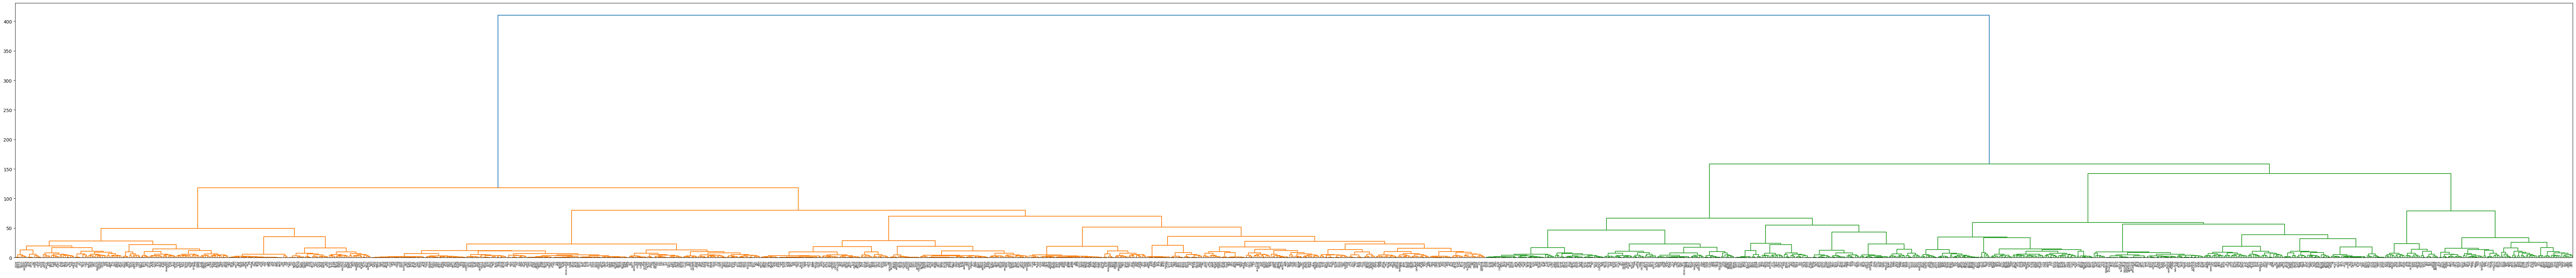

In [145]:
# Get dendogram
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

Z = linkage(corr, 'ward')

plt.figure(figsize=(100, 10))
dendrogram(Z, labels=corr.columns)
plt.show()

In [146]:
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict

# Specify the maximum distance (height in the dendrogram)
max_d = 66# for post recession
# max_d = 28# for recession

# Create clusters
clusters = fcluster(Z, max_d, criterion='distance')

# Map cluster numbers to column names
cluster_dict = defaultdict(list)
for i, cluster_num in enumerate(clusters):
    cluster_dict[cluster_num].append(corr.columns[i])

# Convert the dictionary to a list of lists
cluster_list = list(cluster_dict.values())
len(cluster_list)

9

In [527]:
# Get 
columns = []
for i in cluster_list:
    for j in i:
        columns.append(j)
len(columns)

289

In [141]:
# cluster_list2 = cluster_list

In [152]:
cluster = []
for i in cluster_list2:
    temp = []
    for j in i:
        if j in columns:
            temp.append(j)
    cluster.append(temp)

In [153]:
# Create a dictionary that maps each symbol to its cluster index
symbol_to_cluster = {symbol: i for i, cluster in enumerate(cluster) for symbol in cluster}

# Create the new column
df['cluster'] = df['ibkr-symbol'].map(symbol_to_cluster)
all = df[~df['cluster'].isna()]

all['posiciones_en_bonos'] = round(all['posiciones_en_bonos'] / all['valores_incluidos'] * 100)
all['posiciones_en_acciones'] = round(all['posiciones_en_acciones'] / all['valores_incluidos'] * 100)
all['posiciones_en_efectivo_y_otros'] = round(all['posiciones_en_efectivo_y_otros'] / all['valores_incluidos'] * 100)

pd.set_option('display.max_rows', None)

all = all.sort_values(by=['cluster', 'stars'], ascending= False)
all.sort_values(by='cluster').to_csv('grouped.csv', index=False)

/var/folders/35/xfdc6bm10c98tsfyqbkl8vq80000gn/T/ipykernel_35883/4260409501.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all['posiciones_en_bonos'] = round(all['posiciones_en_bonos'] / all['valores_incluidos'] * 100)
/var/folders/35/xfdc6bm10c98tsfyqbkl8vq80000gn/T/ipykernel_35883/4260409501.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all['posiciones_en_acciones'] = round(all['posiciones_en_acciones'] / all['valores_incluidos'] * 100)
/var/folders/35/xfdc6bm10c98tsfyqbkl8vq80000gn/T/ipykernel

---
### Reduce stocks
---

In [154]:
pd.set_option('display.max_rows', 50)

# Get historical data stats
stats = pd.DataFrame()
for tuple in historical_list:
    symbol = tuple[0]
    values = [tuple[1].open.iloc[0]]
    values += tuple[1].close.to_list()
    values = pd.Series(values).pct_change()
    max_date = tuple[1].date.iloc[-1]
    min_date = tuple[1].date.iloc[0]
    date_range = pd.to_datetime(max_date) - pd.to_datetime(min_date)
    date_range = date_range.days
    max = values.max()
    min = values.min()
    mean = values.mean()
    median = values.median()
    std = values.std()
    temp = pd.DataFrame({'ibkr-symbol': [symbol],
                         'date_range': [date_range],
                         'min': [min],
                         'max': [max],
                         'mean': [mean],
                         'median': [median],
                         'std': [std]})
    stats = pd.concat([stats, temp], ignore_index=False)

In [ ]:
# 2022-05-26 URNU

In [155]:
filtered = all.loc[all['riesgo_estrategico'].isin(['Sólo long','Gestionado activamente'])]
filtered = filtered.loc[filtered['replicacion'].isin(['physical', 'sample'])]
filtered = filtered.loc[filtered['valores_incluidos'] > 1]
filtered['cluster'].value_counts()

cluster
0.0    92
1.0    91
4.0    53
6.0    37
5.0    25
2.0    20
3.0    19
8.0     8
Name: count, dtype: int64

In [231]:
def calculateSemivarSTD(series):
    mean = series.mean()
    semivar = np.mean((series[series < 0] - mean) ** 2)
    return np.sqrt(semivar)

# Assuming 'df' is your DataFrame

def getStatsDf(df):
    semivars = df.apply(calculateSemivarSTD)

    sharpe = semivars.to_frame('semivar_std')
    sharpe['std'] = df.std()
    sharpe['mean'] = df.mean()
    sharpe['sharpe'] = sharpe['mean']/ sharpe['std']
    sharpe['sortino'] = sharpe['mean']/ sharpe['semivar_std']

    return sharpe

In [409]:
list_to_filter = [j for i in cluster_list for j in i]

filtered_list = stats[stats['ibkr-symbol'].isin(list_to_filter)].sort_values(by='mean')['ibkr-symbol'].to_list()

start_date = '2020-01-31'
end_date = '2024-06-30'

# Get data slice
mask = (data['date'] >= start_date) & (data['date'] <= end_date)
filter_subset = data.loc[mask]

temp = ['date'] + filtered_list
filter_subset = filter_subset[temp]

filter_df = filter_subset.drop('date', axis=1).pct_change().drop(filter_subset.index[0]).dropna(axis=1)

/var/folders/35/xfdc6bm10c98tsfyqbkl8vq80000gn/T/ipykernel_35883/1256451219.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  filter_df = filter_subset.drop('date', axis=1).pct_change().drop(filter_subset.index[0]).dropna(axis=1)


In [ ]:
# housing_crash, climb7_18, recession2018, climb18_20, corona, climb21, recession2022, climbpresent

# start_date = '2007-12-31'
# end_date = '2009-03-31'

# start_date = '2018-08-31'
# end_date = '2018-12-31'

# start_date = '2020-01-31'
# end_date = '2020-12-31'

# start_date = '2021-12-31'
# end_date = '2022-12-31'

# '2021-12-31'

In [495]:
# Merge the dataframes
climbs = climbs_all.merge(crash_all, left_index=True, right_index=True, how='outer', suffixes=('', '_y'))

# List of columns in climb_present
cols = climb_present.columns

# # For each column in climb_present
# for col in cols:
#     if col + '_y' in climbs.columns:
#         climbs[col] = (climbs[col] + climbs[col + '_y']) / 2
#         climbs.drop(col + '_y', axis=1, inplace=True)

for col in cols:
    if col + '_y' in climbs.columns:
        climbs[col] = np.where(climbs[[col, col + '_y']].notna().all(axis=1),
                               climbs[[col, col + '_y']].mean(axis=1),
                               climbs[[col, col + '_y']].bfill(axis=1).iloc[:, 0])
        climbs.drop(col + '_y', axis=1, inplace=True)

In [321]:
climb_present = getStatsDf(filter_df).sort_values(by='sharpe')
climb_present

,semivar_std,std,mean,sharpe,sortino
IASP,0.006894,0.007096,-0.000501,-0.070575,-0.072646
HKDE,0.010486,0.011558,-0.000808,-0.069876,-0.077019
NRJ,0.011984,0.012319,-0.000819,-0.066468,-0.068326
BIOT,0.008714,0.009122,-0.000469,-0.051425,-0.053837
CASH,0.009208,0.010641,-0.000451,-0.042343,-0.048935
CNAA,0.008758,0.010196,-0.000410,-0.040249,-0.046860
QCLN,0.020720,0.021326,-0.000672,-0.031495,-0.032415
RIZF,0.008347,0.008355,-0.000214,-0.025657,-0.025682
CHINE,0.014476,0.015844,-0.000345,-0.021768,-0.023825
ASI,0.014053,0.015078,-0.000280,-0.018598,-0.019954


In [487]:
climbs_all.sort_values(by='sharpe')

,semivar_std,std,mean,sharpe,sortino
PEU,0.000470,0.000322,1.262648e-05,-0.197808,-0.200607
C3M,0.000116,0.000094,1.026775e-05,-0.141246,-0.185927
FSOV,0.002498,0.002374,-1.444256e-04,-0.073307,-0.066774
TAT,0.001475,0.001352,-6.356413e-05,-0.067414,-0.052391
MA13,0.000482,0.000537,-4.877131e-06,-0.064681,-0.064946
IGLE,0.002630,0.002737,-8.582410e-05,-0.041896,-0.043139
IMBE,0.003019,0.003049,-3.389397e-05,-0.035887,-0.035056
QCLN,0.020720,0.021326,-6.716507e-04,-0.031495,-0.032415
ASI,0.014310,0.014755,-4.533747e-04,-0.030997,-0.031476
HSTE,0.019883,0.021296,-6.059964e-04,-0.027643,-0.029561


In [488]:
crash_all.sort_values(by='sharpe')

,semivar_std,std,mean,sharpe,sortino
AFLE,0.003618,0.003717,-0.000568,-0.189972,-0.191623
CACM,0.016914,0.016560,-0.003189,-0.181619,-0.184770
EESM,0.016635,0.016911,-0.003159,-0.181235,-0.189381
SMC,0.017499,0.017405,-0.003083,-0.171285,-0.177501
EEA,0.017415,0.017316,-0.002966,-0.165938,-0.168820
UEFD,0.022310,0.022597,-0.002837,-0.164326,-0.168823
IPRP,0.016669,0.016934,-0.002920,-0.163812,-0.172491
DJMC,0.017358,0.016411,-0.002817,-0.162120,-0.159501
SRIC5,0.006228,0.005816,-0.000964,-0.159314,-0.152716
EEP,0.017537,0.017707,-0.002934,-0.159269,-0.160976


In [496]:
climbs.sort_values(by='sharpe')#.to_csv('combined.csv')

,semivar_std,std,mean,sharpe,sortino
PEU,0.000440,0.000378,-0.000006,-0.153602,-0.155341
C3M,0.000130,0.000188,0.000010,-0.111528,-0.097223
TAT,0.001808,0.001683,-0.000160,-0.098648,-0.086212
FSOV,0.003318,0.003366,-0.000320,-0.094174,-0.094121
SRIC3,0.002633,0.002217,-0.000254,-0.089862,-0.082227
SRIC5,0.004313,0.003933,-0.000482,-0.089788,-0.084464
MA13,0.001121,0.001120,-0.000073,-0.080097,-0.084939
V3GE,0.004051,0.004181,-0.000385,-0.080061,-0.083450
EGRI,0.003412,0.003851,-0.000357,-0.080009,-0.091058
CACM,0.013259,0.012560,-0.001371,-0.063865,-0.068549


In [497]:
combined = []
for i in cluster_list:
    combined.append(climbs.reset_index()[climbs.reset_index()['index'].isin(i)])

In [521]:
import pandas as pd
import pickle

with open('short.pkl', 'wb') as f:
    pickle.dump(combined, f)

with open('short.pkl', 'rb') as f:
    df = pickle.load(f)


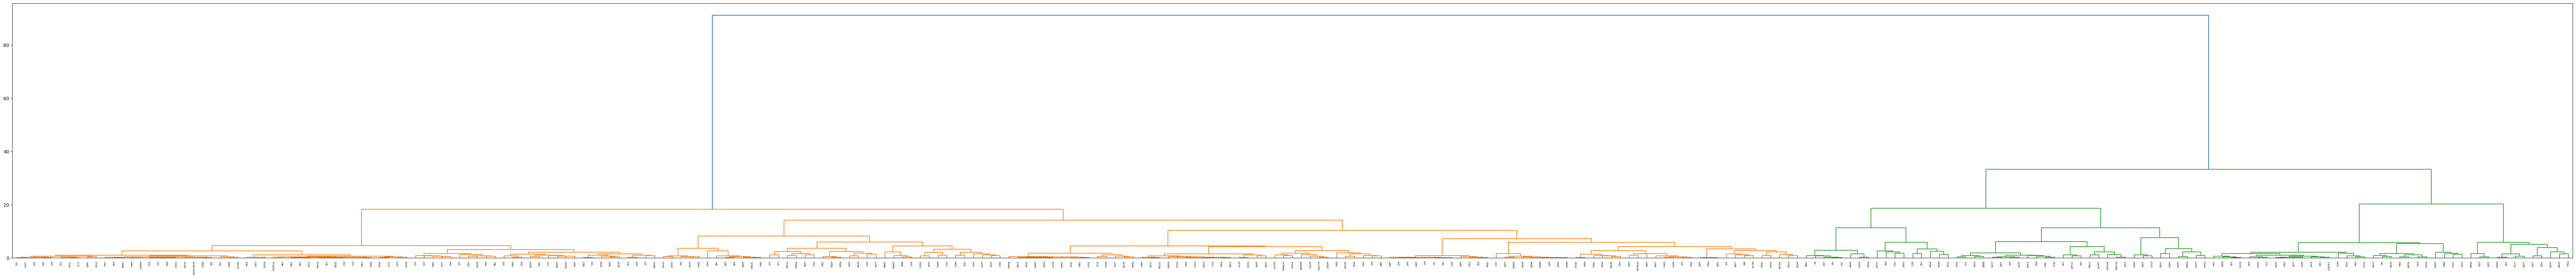

In [410]:
# Get corr2 matrix
corr2 = filter_df.corr()

Z = linkage(corr2, 'ward')

plt.figure(figsize=(100, 10))
dendrogram(Z, labels=corr2.columns)
plt.show()

In [480]:
# Specify the maximum distance (height in the dendrogram)
max_d = 20 # for post recession

# Create clusters
clusters = fcluster(Z, max_d, criterion='distance')

# Map cluster numbers to column names
cluster_dict = defaultdict(list)
for i, cluster_num in enumerate(clusters):
    cluster_dict[cluster_num].append(corr2.columns[i])

# Convert the dictionary to a list of lists
cluster_list = list(cluster_dict.values())
len(cluster_list)

4

In [446]:
# Draw correation heatmap
import numpy as np

corr = corr2[columns].reindex(columns)

plt.figure(figsize=(200, 200))
plt.imshow(corr, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(columns)), columns, rotation=45)
plt.yticks(range(len(columns)), columns)

# # Add correlation numbers
# for i in range(len(corr)):
#     for j in range(len(corr)):
#         text = plt.text(j, i, np.around(corr.iloc[i, j], decimals=2),
#                        ha="center", va="center", color="black")

# Display the plot
plt.show()